In [200]:
import warnings
warnings.filterwarnings("ignore")
import logging

import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




# Parameters

In [201]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"

# Functions

In [202]:
def get_samples_from_dataloader(dataloader, size):
    """
        Return photos1, photos2, ft_numerical, labels
    """ 
    
    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    
    positive_class = 0
    negative_class = 0 
    
    for photos1, photos2, numericalft, labels in dataloader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1
                
            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue 
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1
                
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())
        
        if len(list_of_labels) >= size:
            break
        
    
            
    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels  = np.array(list_of_labels)
    
    return (photos1, photos2, ft_numerical, labels)


In [203]:
def load_model_and_loaders(model_row):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = True if model_row["double_img"].values[0] > 0 else False
    output_tab = model_row["output_tab"].values[0] if model_row["output_tab"].values[0] > 0 else None 
    model, input_size = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model" + ".pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [204]:
def create_explainers(model, device, photos1_train, photos_2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = e.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [205]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [207]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

# Preprocessing

In [208]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
summary.drop_duplicates(inplace=True)

In [209]:
numerical_columns = data.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("label")
ft_size = len(numerical_columns)

In [210]:
features_name = data.iloc[:,5:].columns.values
features_name

array(['gender', 'G', 'T', 'TS', 'NS', 'N', 'NI', 'TI', 'age', 'T/TS',
       'T/NS', 'T/N', 'T/NI', 'T/TI', 'TS/NS', 'TS/N', 'TS/NI', 'TS/TI',
       'NS/N', 'NS/NI', 'NS/TI', 'N/NI', 'N/TI', 'NI/TI'], dtype=object)

In [211]:
summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'is_inception', 'optim',
       'lr', 'epochs', 'double_img', 'output_tab', 'backbone',
       'feature_extract', 'early_start', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version'],
      dtype='object')

In [212]:
summary.shape

(700, 34)

In [213]:
summary = summary.drop_duplicates(subset=['k_fold','frac_val','is_inception', 'optim', 'lr', 'epochs', 'double_img', 'output_tab', 'backbone', 'feature_extract', 'early_start'])

In [214]:
renames_columns = {
    "val_best_auc": "Melhor AUC", "val_avg_auc": "Média AUC",
    "val_best_sp": "Melhor SP", "val_avg_sp": "Média SP",
    "val_best_sn": "Melhor SN", "val_avg_sn": "Média SN",
}

In [215]:
summary["output_tab"] = summary["output_tab"].fillna(0)
summary["double_img"] = summary["double_img"].fillna(0)
summary[OCT_PRESENCE] = np.where(summary['output_tab'] > 0, 'Sim', 'Não')
summary[DUAL_IMAGE] = summary["double_img"].map({0.0: "Não",1.0: "Sim"})

In [216]:
summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'is_inception', 'optim',
       'lr', 'epochs', 'double_img', 'output_tab', 'backbone',
       'feature_extract', 'early_start', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version',
       'Usando OCT', 'Dual Image'],
      dtype='object')

In [218]:
summary

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,Dual Image
0,32affbbcac12427a84e10af5e44db802,NaN,0.2,0.847134,0.790345,1.000000,0.826087,0.769618,0.691058,0.880811,0.501304,0.946755,0.922611,0.976959,0.874251,0.872263,0.822313,0.934747,0.709880,magneto,False,sgd,0.0100,100.0,0.0,0.0,mobile,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
1,89b1209eca2e44eeb1b59061fa687789,NaN,0.2,0.821656,0.776048,1.000000,0.913043,0.725541,0.645374,0.839009,0.451739,0.843594,0.762769,0.953917,0.580838,0.801514,0.703370,0.924286,0.482455,magneto,False,ranger,0.0100,100.0,0.0,0.0,mobile,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
2,0de11e06a2444858bcdfac8ebf136a7a,NaN,0.2,0.707006,0.530454,1.000000,1.000000,0.693949,0.500441,0.967838,0.033043,0.722130,0.508016,1.000000,0.221557,0.718752,0.499651,0.992834,0.006467,magneto,False,adam,0.0100,100.0,0.0,0.0,mobile,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
3,de2371ef299b4e109f4d8cc7b8a16d43,NaN,0.2,0.770701,0.690462,1.000000,1.000000,0.616752,0.550106,0.711081,0.389130,0.787022,0.669714,1.000000,0.443114,0.741414,0.587601,0.933825,0.241377,magneto,False,radam,0.0100,100.0,0.0,0.0,mobile,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
16,30b81c20373c4f6eadc0efd016b987d1,NaN,0.2,0.853503,0.803858,1.000000,0.826087,0.786561,0.720289,0.880360,0.560217,0.936772,0.904185,0.986175,0.838323,0.869900,0.806697,0.948963,0.664431,magneto,False,sgd,0.0100,100.0,0.0,0.0,shuffle,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
17,115fd397b3a946de956560e2011c3f78,NaN,0.2,0.828025,0.784763,1.000000,0.826087,0.772611,0.694702,0.882883,0.506522,0.873544,0.812978,0.993088,0.676647,0.814226,0.714898,0.938479,0.491317,magneto,False,ranger,0.0100,100.0,0.0,0.0,shuffle,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
18,e25d615d543b434c9c3811c2137ad75f,NaN,0.2,0.834395,0.744712,1.000000,0.913043,0.747898,0.649728,0.886847,0.412609,0.833611,0.741121,0.965438,0.532934,0.781198,0.653809,0.940553,0.367066,magneto,False,radam,0.0100,100.0,0.0,0.0,shuffle,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
19,2a9333a060414f748291832bf6f5ae4a,NaN,0.2,0.815287,0.726694,1.000000,0.782609,0.703439,0.555463,0.912883,0.198043,0.806988,0.680324,1.000000,0.413174,0.739717,0.556108,0.969401,0.142814,magneto,False,adam,0.0100,100.0,0.0,0.0,shuffle,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Não
48,0542a79eda184f16a570a16487e91b1a,NaN,0.2,0.853503,0.798277,1.000000,0.804348,0.784777,0.724693,0.869820,0.579565,0.976705,0.970977,1.000000,0.958084,0.906057,0.863063,0.959839,0.766287,magneto,True,sgd,0.0100,100.0,1.0,0.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
49,b55519d3a2ea4402a4b26bbe6c5855b8,NaN,0.2,0.713376,0.565511,1.000000,0.239130,0.706369,0.501204,0.996757,0.005652,0.723794,0.517267,1.000000,0.059880,0.721015,0.500186,0.997258,0.003114,magneto,True,radam,0.0100,100.0,1.0,0.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim


# Violin

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'mobile'),
  Text(1, 0, 'shuffle'),
  Text(2, 0, 'inception'),
  Text(3, 0, 'vit'),
  Text(4, 0, 'resnet'),
  Text(5, 0, 'regnet'),
  Text(6, 0, 'regnet16'),
  Text(7, 0, 'regnet32'),
  Text(8, 0, 'regnetx'),
  Text(9, 0, 'regnet16x'),
  Text(10, 0, 'regnet32x'),
  Text(11, 0, 'efficient')])

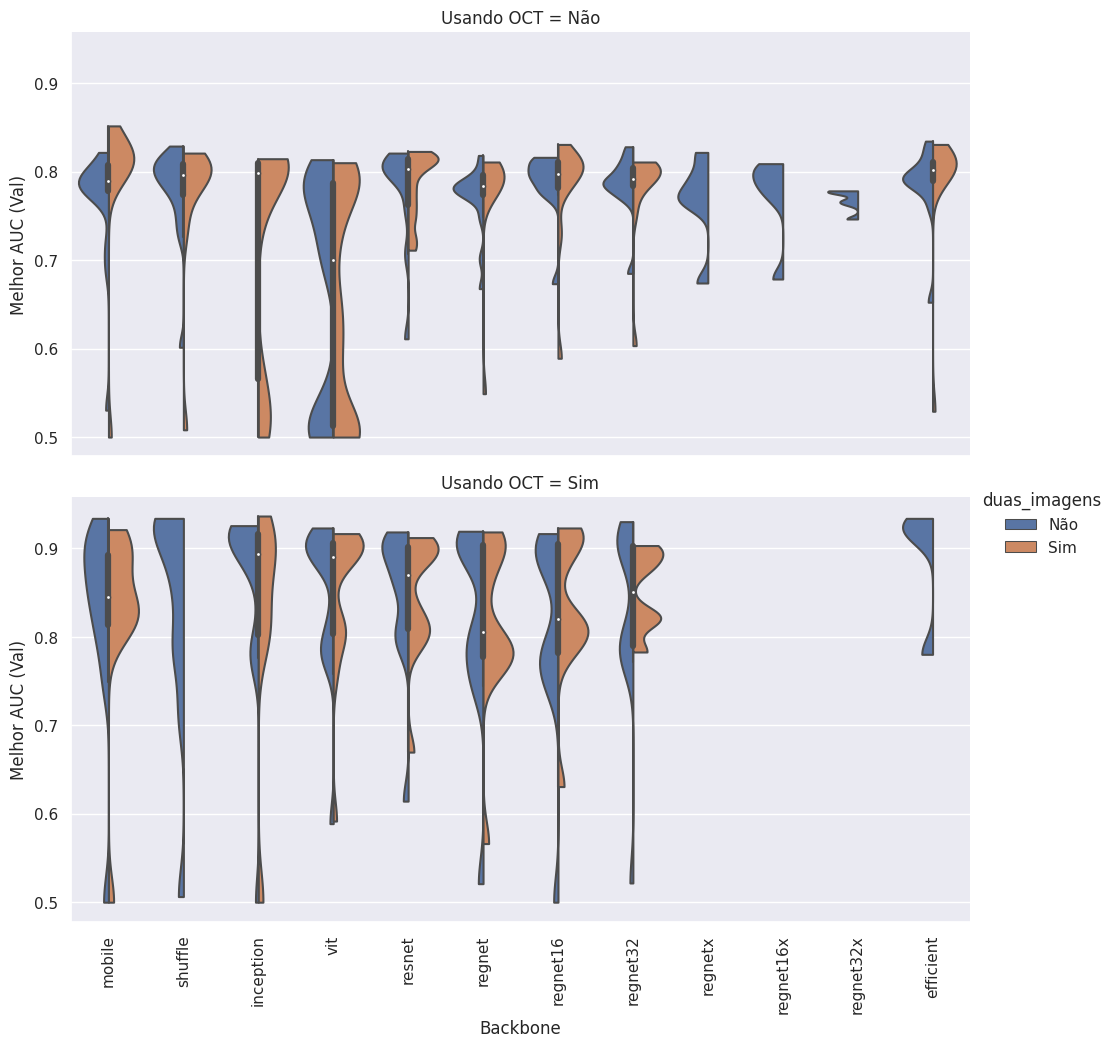

In [98]:
g = sns.catplot(
    data=summary, x="backbone", y="val_best_auc",hue=double_img,row=oct_presence,
    kind="violin", bw=.25, cut=0,split=True, height=5, aspect=2)
g.set_ylabels("Melhor AUC (Val)", fontsize=12) # not set_label
g.set_xlabels("Backbone", fontsize=12) # not set_label
pyplot.xticks(rotation=90)

# Estatística da média e do máximo

## Backbone

In [19]:
summary[['val_best_auc','val_avg_auc','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0)

backbone val_best_auc                   val_avg_auc                  
                       min   max  mean   std         min   max  mean   std
0   efficient         0.55  0.80  0.76  0.06        0.50  0.72  0.67  0.06
1   inception         0.50  0.94  0.79  0.14        0.50  0.86  0.70  0.12
2      mobile         0.50  0.93  0.79  0.09        0.50  0.84  0.70  0.08
3      regnet         0.52  0.92  0.79  0.08        0.50  0.84  0.71  0.07
4    regnet16         0.50  0.92  0.80  0.08        0.50  0.84  0.71  0.07
5   regnet16x         0.68  0.81  0.77  0.05        0.59  0.74  0.69  0.05
6    regnet32         0.52  0.93  0.80  0.08        0.50  0.83  0.72  0.07
7   regnet32x         0.75  0.78  0.77  0.01        0.63  0.72  0.68  0.04
8     regnetx         0.67  0.82  0.77  0.05        0.58  0.72  0.68  0.05
9      resnet         0.61  0.92  0.80  0.07        0.51  0.83  0.70  0.08
10    shuffle         0.60  0.83  0.78  0.05        0.53  0.73  0.68  0.06
11        vit         0.50  0.92  0.72  0.15        0.50  0.85  0.64  0.12

In [18]:
latex = summary[['val_best_auc','val_avg_auc','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:aucbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a AUC")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [19]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_auc.tex", 'w') as table:
    table.write(latex)

In [20]:
latex = summary[['val_best_sp','val_avg_sp','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:spbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a especificidade")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [21]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_sp.tex", 'w') as table:
    table.write(latex)

In [22]:
latex = summary[['val_best_sn','val_avg_sn','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:snbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a sensibilidade")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [23]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_sn.tex", 'w') as table:
    table.write(latex)

## Double Image e OCT

In [24]:
summary[['val_best_auc','val_avg_auc',oct_presence,double_img]].groupby([double_img,oct_presence]).agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0)

duas_imagens Usando OCT val_best_auc                   val_avg_auc        \
                                   min   max  mean   std         min   max   
0          Não        Não          0.5  0.83  0.76  0.08         0.5  0.74   
1          Não        Sim          0.5  0.93  0.85  0.10         0.5  0.86   
2          Sim        Não          0.5  0.85  0.73  0.11         0.5  0.76   
3          Sim        Sim          0.5  0.94  0.84  0.10         0.5  0.84   

               
   mean   std  
0  0.67  0.07  
1  0.75  0.09  
2  0.66  0.10  
3  0.74  0.09

In [25]:
latex = summary[['val_best_auc','val_avg_auc', oct_presence,double_img]].groupby([double_img,oct_presence]).agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index([double_img,oct_presence]).to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:aucdboct",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquitetura dos modelos, separado por uso de duas imagens e OCT")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [26]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_double_oct_auc.tex", 'w') as table:
    table.write(latex)

## Modelos TOP

In [27]:
summary['rank_max_auc'] = summary["val_best_auc"].rank(ascending=False,method="first").astype(int)
summary['rank_avg_auc'] = summary["val_avg_auc"].rank(ascending=False,method="first").astype(int)

In [28]:
summary.sort_values("rank_max_auc")

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens,rank_max_auc,rank_avg_auc
94,e4be89e62af347ebb6889e03f3bb6a4f,NaN,0.2,0.955414,0.936643,1.000000,0.956522,0.870955,0.813581,0.952162,0.675000,0.961730,0.948405,1.000000,0.922156,0.925474,0.890341,0.969424,0.811257,magneto,True,radam,0.0100,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,1,28
624,8278647f88394f01a7caab2ade3d8295,NaN,0.2,0.942675,0.933999,1.000000,0.913043,0.891783,0.843396,0.960270,0.726522,0.981697,0.976276,0.993088,0.964072,0.940832,0.914089,0.974286,0.853892,magneto,False,adam,0.0010,100.0,0.0,5.0,mobile,False,100.0,2022-11-07 06:56:10.493098,04:24:22.68,04:24:22.68,0.13.0+cu113,1.12.0+cu113,Sim,Não,2,8
93,cfe7535b4f3541adbc365ad1b82411f9,NaN,0.2,0.949045,0.929495,1.000000,0.913043,0.893503,0.842003,0.966396,0.717609,0.970050,0.960843,1.000000,0.940120,0.932879,0.896278,0.978664,0.813892,magneto,True,ranger,0.0100,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,3,10
77,63d6a93a02c1451fa2d0deb5537c228a,NaN,0.2,0.949045,0.925774,1.000000,0.913043,0.912102,0.863176,0.981351,0.745000,0.960067,0.944721,0.993088,0.910180,0.928403,0.888942,0.977765,0.800120,magneto,True,adam,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,4,1
79,a4fe240bc5ed47c49e505b092f9ac61e,NaN,0.2,0.942675,0.924990,1.000000,0.913043,0.842930,0.782304,0.928739,0.635870,0.986689,0.983416,1.000000,0.976048,0.902579,0.851280,0.966751,0.735808,magneto,True,sgd,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,5,47
78,0c3ba6344db246a4b808bc1f0b19c624,NaN,0.2,0.949045,0.923130,1.000000,0.956522,0.899299,0.845720,0.975135,0.716304,0.971714,0.950944,1.000000,0.910180,0.930250,0.888877,0.982005,0.795749,magneto,True,ranger,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,6,4
197,04ff79a9ee5d4750812696e16fe0e713,NaN,0.2,0.942675,0.923130,1.000000,0.913043,0.895605,0.842662,0.970541,0.714783,0.966722,0.947488,1.000000,0.916168,0.925308,0.886744,0.973548,0.799940,loki,False,radam,0.0100,100.0,0.0,5.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,7,9
76,9f0029183aca436fb265dad66303f671,NaN,0.2,0.942675,0.921269,1.000000,0.956522,0.897643,0.844549,0.972793,0.716304,0.963394,0.948867,1.000000,0.922156,0.930083,0.892519,0.977074,0.807964,magneto,True,radam,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,8,5
180,38a1722691744c27823fc408d7fd253b,NaN,0.2,0.949045,0.919409,1.000000,0.847826,0.852484,0.794089,0.935135,0.653043,0.958403,0.934359,1.000000,0.880240,0.903311,0.851474,0.968157,0.734790,magneto,True,ranger,0.0005,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,9,40
185,4d9886e7326a445cba8ee17c0fab421c,NaN,0.2,0.949045,0.919409,1.000000,0.869565,0.867707,0.810902,0.948108,0.673696,0.965058,0.946335,0.990783,0.904192,0.915291,0.871502,0.970069,0.772934,magneto,True,radam,0.0010,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,10,30


In [29]:
summary['rank_max_auc_oct_double'] = summary.groupby([double_img,oct_presence])["val_best_auc"].rank(ascending=False,method="first").astype(int)
summary['rank_avg_auc_oct_double'] = summary.groupby([double_img,oct_presence])["val_avg_auc"].rank(ascending=False,method="first").astype(int)

In [30]:
summary["rank_avg"] = summary[["rank_max_auc_oct_double","rank_avg_auc_oct_double","rank_max_auc","rank_avg_auc"]].mean(axis=1)

In [31]:
summary.groupby("backbone")["rank_avg"].mean().astype(int).to_frame().reset_index().set_index("backbone")

,rank_avg
backbone,
efficient,190
inception,109
mobile,152
regnet,146
regnet16,125
regnet16x,160
regnet32,141
regnet32x,204
regnetx,183


In [32]:
latex = summary.groupby("backbone")["rank_avg"].mean().astype(int).to_frame().reset_index().to_latex(column_format="|>{\\bfseries}c|c|",
            bold_rows=True,
            index=False,
            escape=True,   
            label="tab:rankingbackbone",
            caption="Rank médio dos backbones considerando todas as arquiteturas visuais.")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [33]:
with open("../thesis/ppgccufmg/exemplo/tables/ranking_backbone.tex", 'w') as table:
    table.write(latex)

# Explicabilidade 

In [196]:
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)

In [69]:
display(summary[(summary[double_img] == "Sim") & (summary[oct_presence] == "Não")].sort_values("val_best_auc"))

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
376,fd994c09312d41879a795700c3041bc9,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.509210,1.000000,0.029940,0.722130,0.500092,0.999885,0.000299,magneto,True,sgd,0.0001,100.0,1.0,0.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
182,8e2c3d2cb39c4787bbe64f6bf75346d1,NaN,0.2,0.707006,0.500000,1.000000,1.000000,0.702866,0.500000,0.990000,0.010000,0.722130,0.522779,1.000000,0.137725,0.720616,0.499780,0.996866,0.002695,magneto,False,ranger,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
181,489254867d9441f2aa305fb6825bc2a6,NaN,0.2,0.707006,0.500000,1.000000,1.000000,0.702866,0.500000,0.990000,0.010000,0.722130,0.540509,1.000000,0.191617,0.720666,0.500570,0.995991,0.005150,magneto,False,radam,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
554,e17cc3900fc542f899d9791135e52c50,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.733777,0.520958,1.000000,0.041916,0.722679,0.501117,0.999839,0.002395,magneto,False,sgd,0.0001,100.0,1.0,0.0,mobile,False,100.0,2022-11-06 18:46:46.024690,04:49:00.10,04:49:00.10,0.13.0+cu113,1.12.0+cu113,Não,Sim
176,ef79ace3dfb24e7ca8285642a5af9215,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.515619,1.000000,0.215569,0.721131,0.500174,0.997535,0.002814,magneto,False,adam,0.0010,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
393,489254867d9441f2aa305fb6825bc2a6,NaN,0.2,0.707006,0.500000,1.000000,1.000000,0.702866,0.500000,0.990000,0.010000,0.722130,0.540509,1.000000,0.191617,0.720666,0.500570,0.995991,0.005150,magneto,False,radam,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
385,b83d30d2512c441ba160712ccd83ed1c,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.504774,1.000000,0.281437,0.720948,0.500048,0.997281,0.002814,magneto,False,adam,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
173,b83d30d2512c441ba160712ccd83ed1c,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.504774,1.000000,0.281437,0.720948,0.500048,0.997281,0.002814,magneto,False,adam,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
394,8e2c3d2cb39c4787bbe64f6bf75346d1,NaN,0.2,0.707006,0.500000,1.000000,1.000000,0.702866,0.500000,0.990000,0.010000,0.722130,0.522779,1.000000,0.137725,0.720616,0.499780,0.996866,0.002695,magneto,False,ranger,0.0100,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim
388,ef79ace3dfb24e7ca8285642a5af9215,NaN,0.2,0.707006,0.500000,1.000000,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.515619,1.000000,0.215569,0.721131,0.500174,0.997535,0.002814,magneto,False,adam,0.0010,100.0,1.0,0.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Não,Sim


## One image 

In [70]:
model_id = "e17cc3900fc542f899d9791135e52c50"
row = summary[summary["model_id"] == model_id]

In [71]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
663,9c522e7d858d4355853e77945f37afb6,NaN,0.2,0.707006,0.508226,1.0,0.043478,0.706943,0.500082,0.99973,0.000435,0.72213,0.5,1.0,0.203593,0.721032,0.499866,0.997696,0.002036,magneto,False,sgd,0.0001,100.0,1.0,0.0,shuffle,False,100.0,2022-11-12 05:49:11.992309,04:11:36.87,04:11:36.87,0.13.0+cu113,1.12.0+cu113,Não,Sim


In [72]:
model_name = row["backbone"].values[0]
pretrained = False
feature_extract = False
double_img_bool = True if row["double_img"].values[0] > 0 else False
output_tab = row["output_tab"].values[0] if row["output_tab"].values[0] > 0 else None 

In [73]:
model, _ = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)

Using 'weights' as positional parameter(s) is deprecated since 0.13 and will be removed in 0.15. Please use keyword parameter(s) instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.


In [74]:
model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model" + ".pth"))

<All keys matched successfully>

In [75]:
model_id

'9c522e7d858d4355853e77945f37afb6'

In [76]:
train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + ".pth")
val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + ".pth")

In [77]:
batch_val = next(iter(val_loader))
batch_train = next(iter(train_loader))

In [69]:
photos1_train, photos2_train, ft_numerical_train , labels_train = batch_train
photos1_val, photos2_val, ft_numerical_val , labels_val = batch_val

In [81]:
torchsummary(model, input_data=photos1)

Layer (type:depth-idx)                                  Output Shape              Param #
RegNet                                                  [16, 1]                   --
├─SimpleStemIN: 1-1                                     [16, 32, 112, 112]        --
│    └─Conv2d: 2-1                                      [16, 32, 112, 112]        864
│    └─BatchNorm2d: 2-2                                 [16, 32, 112, 112]        64
│    └─ReLU: 2-3                                        [16, 32, 112, 112]        25,690,112
├─Sequential: 1-2                                       [16, 672, 7, 7]           --
│    └─AnyStage: 2-4                                    [16, 64, 56, 56]          --
│    │    └─ResBottleneckBlock: 3-1                     [16, 64, 56, 56]          77,088,256
│    └─AnyStage: 2-5                                    [16, 128, 28, 28]         --
│    │    └─ResBottleneckBlock: 3-2                     [16, 128, 28, 28]         38,587,392
│    │    └─ResBottleneckBlock: 3-3

In [70]:
e = shap.DeepExplainer(model, photos1_train)

In [71]:
shap_values = e.shap_values(photos1_val)

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


In [153]:
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
test_numpy = np.swapaxes(np.swapaxes(photos1_val.numpy(), 1, -1), 1, 2)

In [188]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [189]:
only_image =  imshow(photos1_val[10].reshape(3,224,224))

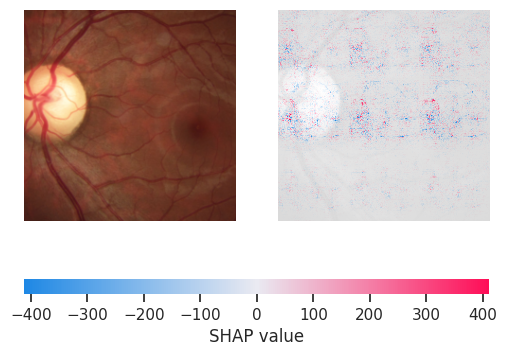

In [191]:
shap.image_plot(shap_values.reshape(16,224,224,3)[10],  only_image.reshape(224,224,3),width=20,aspect=0.2)

## Two images

In [199]:
model_id = "9c522e7d858d4355853e77945f37afb6"
row = summary[summary["model_id"] == model_id]
model, train_loader, val_loader, input_size =  load_model_and_loaders(row)
photos1_train, photos2_train, ft_numerical_train, labels_train =  get_samples_from_dataloader(train_loader, total_train_samples)
photos1_val, photos2_val, ft_numerical_val, labels_val =  get_samples_from_dataloader(val_loader, total_test_samples)
shap_values_photo1, shap_values_photo2, shap_values_numerical, photos1_numpy, photos2_numpy =\
    create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                      photos1_val, photos2_val, ft_numerical_val,input_size)

Criando shuffle +  True  +  None


In [171]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version
663,9c522e7d858d4355853e77945f37afb6,NaN,0.2,0.707006,0.508226,1.0,0.043478,0.706943,0.500082,0.99973,0.000435,0.72213,0.5,1.0,0.203593,0.721032,0.499866,0.997696,0.002036,magneto,False,sgd,0.0001,100.0,1.0,NaN,shuffle,False,100.0,2022-11-12 05:49:11.992309,04:11:36.87,04:11:36.87,0.13.0+cu113,1.12.0+cu113


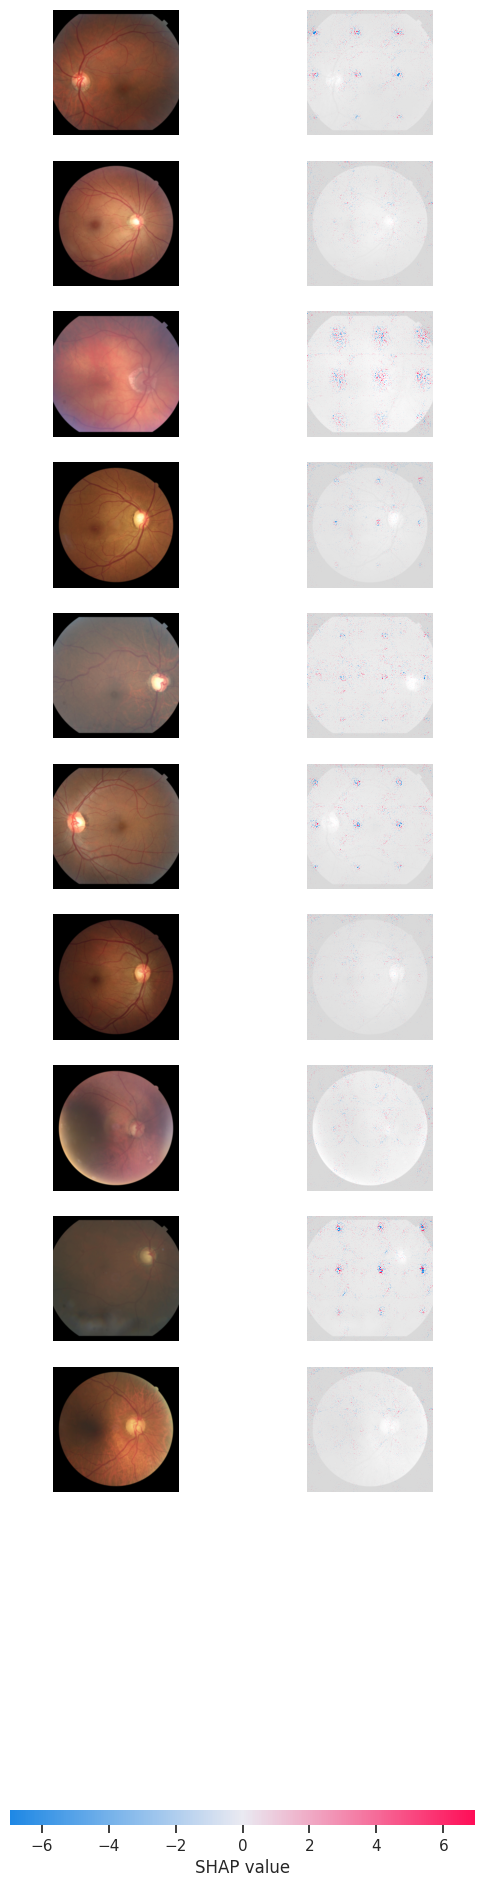

In [197]:
total_plot_images = 10
plot_image(shap_values_photo1, photos1_numpy, total_plot_images)

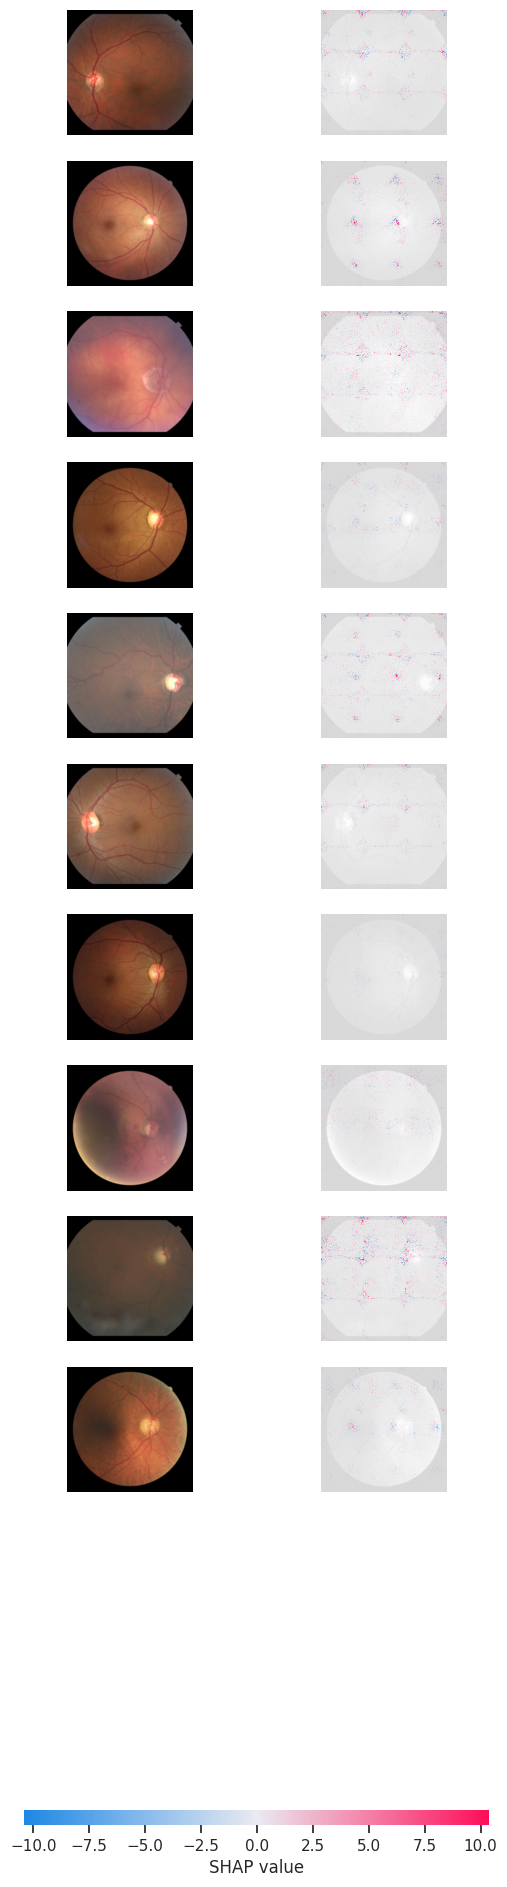

In [198]:
total_plot_images = 10
plot_image(shap_values_photo2, photos1_numpy, total_plot_images)

## One image and OCT

In [18]:
model_id = "63d6a93a02c1451fa2d0deb5537c228a"
row = summary[summary["model_id"] == model_id]

In [19]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
77,63d6a93a02c1451fa2d0deb5537c228a,NaN,0.2,0.949045,0.925774,1.0,0.913043,0.912102,0.863176,0.981351,0.745,0.960067,0.944721,0.993088,0.91018,0.928403,0.888942,0.977765,0.80012,magneto,True,adam,0.01,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não


In [20]:
model_name = row["backbone"].values[0]
pretrained = False
feature_extract = False
double_img_bool = True if row["double_img"].values[0] > 0 else False
output_tab = int(row["output_tab"].values[0]) if row["output_tab"].values[0] > 0 else None 

In [21]:
model, _ = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)

Using 'weights' as positional parameter(s) is deprecated since 0.13 and will be removed in 0.15. Please use keyword parameter(s) instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.


In [22]:
model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + str(model_id) + ".pth"))

<All keys matched successfully>

In [23]:
train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader_" + str(model_id) + ".pth")
val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader_" + str(model_id) + ".pth")

In [24]:
val_loader.dataset.root_dir = ROOT_DIR
train_loader.dataset.root_dir = ROOT_DIR

In [25]:
device = torch.device('cuda:1')
model = model.to(device)

In [92]:
photos1_train, photos2_train, ft_numerical_train, labels_train, photos1_val, photos2_val, ft_numerical_val, labels_val =\
    get_samples_from_dataloader(train_loader,val_loader,total_train_samples,total_test_samples)

In [96]:
xplainer_multi_pos = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])

In [112]:
shap_values_photo1, shap_values_photo2, shap_values_numerical = xplainer_multi_pos.shap_values([torch.from_numpy(np.stack(photos1_val[:total_test_samples])).to(device),
                                                    torch.from_numpy(np.stack(photos2_val[:total_test_samples])).to(device),
                                                    torch.from_numpy(np.stack(ft_numerical_val[:total_test_samples])).to(device)])

In [184]:
index = 8
only_image_1 =  imshow(test_numpy[index].reshape(3,299,299))

In [185]:
photos1_val.shape

torch.Size([10, 3, 299, 299])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

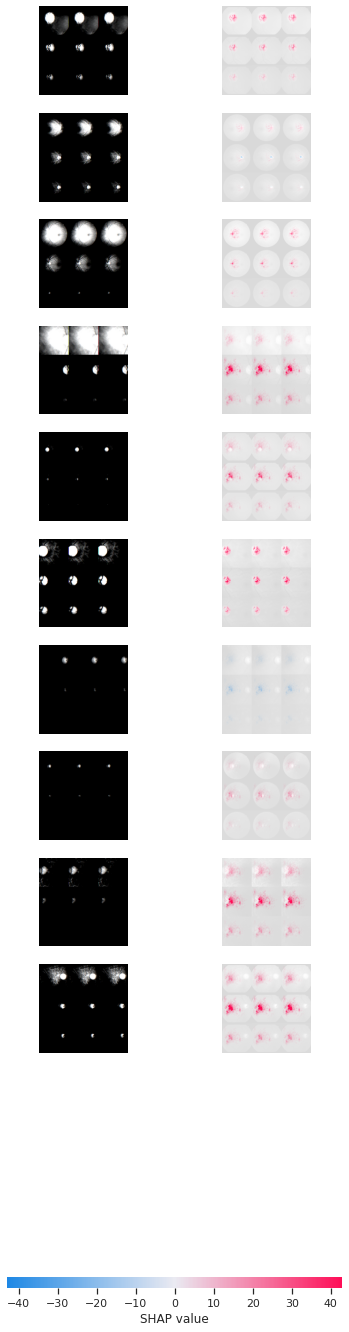

In [186]:
shap.image_plot(shap_values_photo1.reshape(-1,299,299,3),  photos1_val.numpy().reshape(-1,299,299,3),width=20,aspect=0.2)

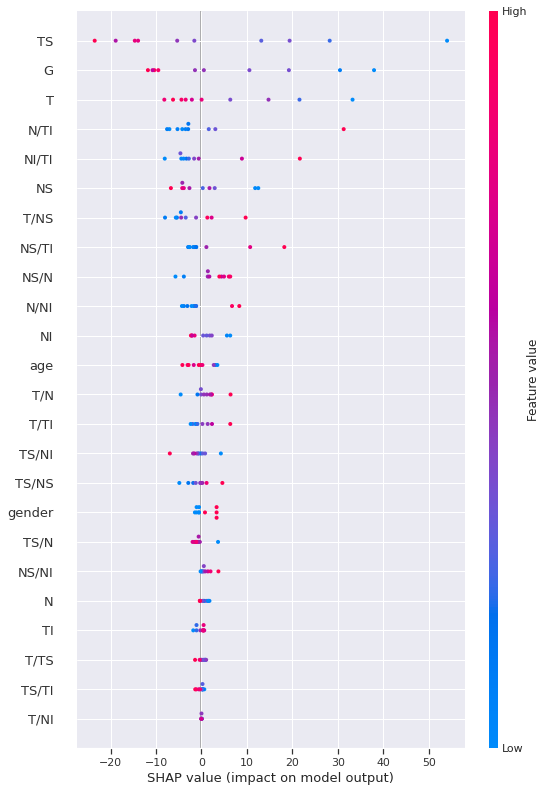

In [125]:
shap.summary_plot( shap_values_numerical,ft_numerical_val, features_name,max_display=30)

In [193]:
logger.setLevel(old_level)

# Benefícios 

- Regnet é flexível, e é possível escolher arquiteturas que contém masi parametros de treinamento para melhor acurácia 
- Pode ser usada em grande escala
- Pode ser utilizada em dispositivos pequenos como Mobile 
- Pode ser treinado com um número menor de imagens, sem a necessidade de coletar um número grande. 
- É eficiente, considerando a tabela abaixo
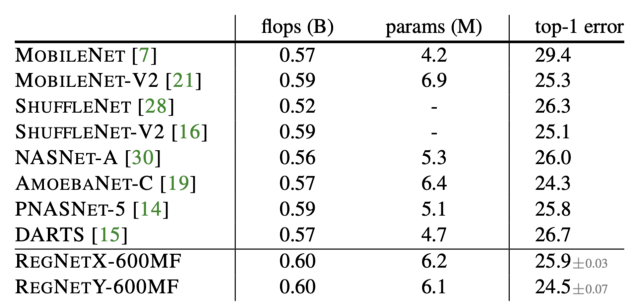
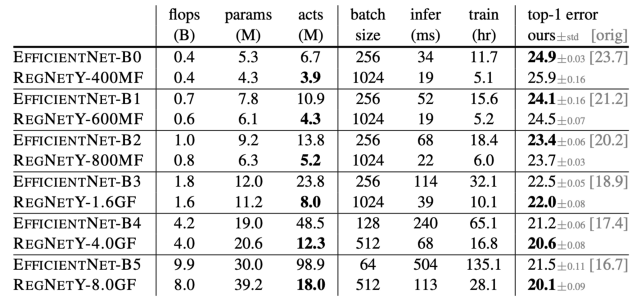